# L4b Advanced: Monte Carlo Versus the Closed Form

The L4b lecture derived the probability that a scheduled long position clears a target return in closed form, and it also gave pseudo-code for simulating GBM price paths by Monte Carlo. This notebook puts the two together. We estimate the target probability by simulation, attach a standard error to the estimate, and watch it converge to the closed form as the number of paths grows. Then we ask what happens if the simulation uses a naive time-stepping scheme instead of the exact one-step transition of the lecture: the Euler scheme is biased for coarse steps, and the bias shows up directly in the probability. We finish with a simple variance-reduction trick that makes every simulated path count for more.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Estimate a probability by simulation with an error bar:** Compute the Monte Carlo estimate of the target probability as an indicator average, attach its binomial standard error, and show convergence to the closed form at the rate of one over the square root of the number of paths.
> * **Distinguish exact from approximate simulation:** Compare the exact one-step GBM transition with the Euler time-stepping scheme, quantify the Euler bias in the terminal mean and in the target probability, and see it vanish as the step shrinks.
> * **Reduce Monte Carlo variance:** Use antithetic variates to cut the standard error of the probability estimate, and explain why the trick works for a monotone target event.

Let's get started!

___

## Setup, Data, and Prerequisites

We use the constant-parameter GBM of the lecture, its exact one-step transition, and the closed-form target probability as the reference. The local [`Include.jl`](Include.jl) file activates the course project and loads the required packages.

The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, [`Include.jl`](Include.jl), in the notebook's global scope. The [`Include.jl`](Include.jl) file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The [`Include.jl`](Include.jl) file activates the course project and loads [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for tabular results, [the `Distributions.jl` package](https://juliastats.org/Distributions.jl/stable/) for the normal distribution, [the `Plots.jl` package](https://docs.juliaplots.org/stable/) for figures, [the `PrettyTables.jl` package](https://ronisbr.github.io/PrettyTables.jl/stable/) for tables, and the [`Random`](https://docs.julialang.org/en/v1/stdlib/Random/) and [`Statistics`](https://docs.julialang.org/en/v1/stdlib/Statistics/) standard libraries for the simulations. This notebook defines its own functions, so no local source files are loaded. Let's set the plotting defaults:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

___

## 1. The Monte Carlo estimate and its standard error

For a scheduled long position, let $T=N\Delta t$ be the holding period in years, let $g_y$ be the continuously compounded annual growth rate associated with the selected benchmark yield $y$, and let $\rho_{\star}>-1$ be the target scaled NPV. The lecture showed that the scaled NPV clears the target exactly when the terminal log-price ratio clears a threshold:
$$
\rho_{T}>\rho_{\star}\quad\Longleftrightarrow\quad\ln\frac{S_{T}}{S_{0}}>\ln(1+\rho_{\star})+g_{y}T,
\qquad
\mathbb{P}(\rho_{T}>\rho_{\star})=1-\Phi\!\left(\frac{\ln(1+\rho_{\star})+g_{y}T-\bar g\,T}{\sigma\sqrt{T}}\right),
$$
with $\bar g=\mu-\sigma^{2}/2$. The Monte Carlo version simulates $M$ price paths with the exact one-step transition $S_{t_{j}}=S_{t_{j-1}}\exp[\bar g\,\Delta t+\sigma\sqrt{\Delta t}\,Z_{j}]$, computes $\rho_{T}$ on each, and averages the indicator of the event. Because each indicator is a Bernoulli draw with success probability $p$, the average $\hat p$ has standard error $\sqrt{p(1-p)/M}$, which we estimate by plugging in $\hat p$. Let's fix the parameters (the same ones as the lattice-limit notebook, over a one-quarter holding period) and compute the closed form:

In [3]:
S₀ = 100.0      # initial share price (USD/share)
μ = 0.15        # arithmetic GBM drift (1/years)
σ = 0.30        # GBM volatility (1/sqrt(years))
T = 63/252      # holding period (years), one trading quarter of daily steps
N = 63          # number of daily steps
g_y = 0.05      # continuous annual rate for the selected benchmark yield y (1/years)
ρ_star = 0.10   # target scaled NPV ρ⋆
ḡ = μ - 0.5*σ^2 # mean growth rate

target_probability(ḡ::Real, σ::Real, T::Real, g_y::Real, ρ_star::Real) =
    1 - cdf(Normal(), (log(1 + ρ_star) + g_y*T - ḡ*T)/(σ*sqrt(T)))

p_exact = target_probability(ḡ, σ, T, g_y, ρ_star)
println("Closed form: P(ρ_T > $(ρ_star)) = $(round(p_exact, digits = 6))")

Closed form: P(ρ_T > 0.1) = 0.293312


Now let's write the simulator. It follows the lecture's pseudo-code exactly (one path at a time, $N$ exact steps, fresh independent shocks), records $\rho_{T}$ for each path, and returns the indicator average and its standard error. We put it in a function so that Julia compiles the loops:

In [4]:
function simulate_target_probability(S₀::Real, μ::Real, σ::Real, T::Real, N::Int, g_y::Real, ρ_star::Real;
        number_of_paths::Int = 100_000, seed::Int = 5660)
    rng = MersenneTwister(seed)
    Δt = T/N
    drift = (μ - 0.5*σ^2)*Δt
    shock = σ*sqrt(Δt)
    discount = exp(-g_y*T)
    hits = 0
    for _ ∈ 1:number_of_paths
        S = S₀
        for _ ∈ 1:N
            S *= exp(drift + shock*randn(rng))   # exact one-step GBM transition
        end
        ρ_T = (S/S₀)*discount - 1               # scaled NPV of the scheduled trade
        hits += (ρ_T > ρ_star)
    end
    p_hat = hits/number_of_paths
    return (probability = p_hat, standard_error = sqrt(p_hat*(1 - p_hat)/number_of_paths), number_of_paths = number_of_paths)
end

simulate_target_probability(S₀, μ, σ, T, N, g_y, ρ_star; number_of_paths = 100_000)

(probability = 0.29404, standard_error = 0.0014407653466126952, number_of_paths = 100000)

Let's run the simulator for path counts from one hundred to one million and record the estimate, its standard error, and the error against the closed form, in the `convergence_table::DataFrame` variable:

In [5]:
convergence_table = let
    df = DataFrame(M = Int[], estimate = Float64[], standard_error = Float64[], error = Float64[], error_in_se = Float64[])
    for M ∈ (100, 1_000, 10_000, 100_000, 1_000_000)
        r = simulate_target_probability(S₀, μ, σ, T, N, g_y, ρ_star; number_of_paths = M)
        push!(df, (M, r.probability, r.standard_error, r.probability - p_exact, (r.probability - p_exact)/r.standard_error))
    end
    df
end
pretty_table(convergence_table; formatters = [fmt__printf("%.5f", [2,3,4]), fmt__printf("%.2f", [5])])

┌─────────┬──────────┬────────────────┬──────────┬─────────────┐
│       M │ estimate │ standard_error │    error │ error_in_se │
│   Int64 │  Float64 │        Float64 │  Float64 │     Float64 │
├─────────┼──────────┼────────────────┼──────────┼─────────────┤
│     100 │  0.33000 │        0.04702 │  0.03669 │        0.78 │
│    1000 │  0.28900 │        0.01433 │ -0.00431 │       -0.30 │
│   10000 │  0.28810 │        0.00453 │ -0.00521 │       -1.15 │
│  100000 │  0.29404 │        0.00144 │  0.00073 │        0.51 │
│ 1000000 │  0.29292 │        0.00046 │ -0.00039 │       -0.85 │
└─────────┴──────────┴────────────────┴──────────┴─────────────┘


The estimate wanders around the closed form by an amount comparable to its standard error, and the standard error falls by a factor of $\sqrt{10}$ for every tenfold increase in paths. That $1/\sqrt{M}$ rate is the price of Monte Carlo: one more decimal place costs one hundred times more paths. Let's plot the estimates with their 95% bands against the closed form:

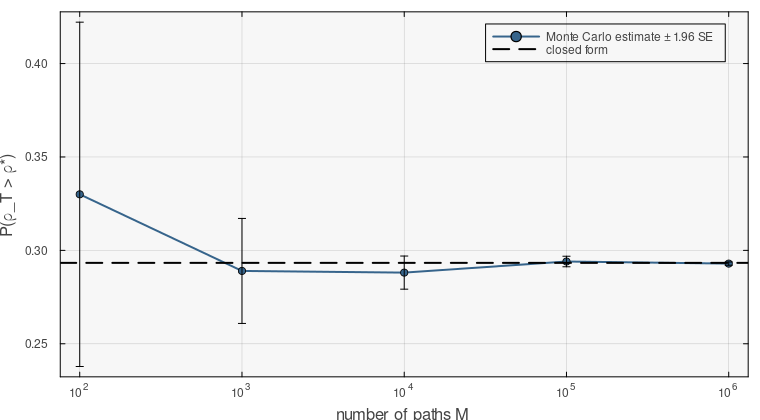

In [6]:
let
    M = convergence_table.M
    est = convergence_table.estimate
    se = convergence_table.standard_error
    plot(M, est; xscale = :log10, yerror = 1.96 .* se, marker = :circle, color = :steelblue4,
        label = "Monte Carlo estimate ± 1.96 SE", xlabel = "number of paths M", ylabel = "P(ρ_T > ρ*)",
        size = (760, 420), legend = :topright)
    hline!([p_exact]; color = :black, linestyle = :dash, label = "closed form")
end

___

## 2. Exact transition versus the Euler scheme

The lecture insisted that its one-step transition is exact at the grid points, not a time-stepping approximation. To see what the alternative costs, replace it with the Euler scheme, which discretizes the SDE $dS=\mu S\,dt+\sigma S\,dW$ directly:
$$
S_{t_{j}}=S_{t_{j-1}}\bigl(1+\mu\,\Delta t+\sigma\sqrt{\Delta t}\,Z_{j}\bigr).
$$
This is not exact for any $\Delta t>0$. Its terminal mean is $S_{0}(1+\mu\Delta t)^{N}$ rather than $S_{0}e^{\mu T}$, its terminal distribution is not lognormal, and for a large enough shock the price can go negative. All three errors vanish as $\Delta t\to0$ (the scheme converges), but for coarse steps they are visible. Let's write an Euler simulator alongside the exact one and compare them over a one-year horizon as the number of steps ranges from one (annual steps) to 252 (daily), keeping the target and benchmark as before:

In [7]:
function simulate_terminal(S₀::Real, μ::Real, σ::Real, T::Real, N::Int; scheme::Symbol = :exact,
        number_of_paths::Int = 200_000, seed::Int = 5660)
    rng = MersenneTwister(seed)
    Δt = T/N
    S_T = zeros(Float64, number_of_paths)
    negatives = 0
    for m ∈ 1:number_of_paths
        S = S₀
        for _ ∈ 1:N
            Z = randn(rng)
            if scheme == :exact
                S *= exp((μ - 0.5*σ^2)*Δt + σ*sqrt(Δt)*Z)   # exact transition
            else
                S *= 1 + μ*Δt + σ*sqrt(Δt)*Z                # Euler step
            end
        end
        negatives += (S <= 0)
        S_T[m] = S
    end
    return (S_T = S_T, negatives = negatives)
end

euler_table = let
    T_year = 1.0
    df = DataFrame(N = Int[], Δt = Float64[], exact = Float64[], euler = Float64[], probability_error = Float64[],
        euler_mean = Float64[], neg = Int[])
    p_closed = target_probability(ḡ, σ, T_year, g_y, ρ_star)
    for N_year ∈ (1, 2, 4, 12, 52, 252)
        ex = simulate_terminal(S₀, μ, σ, T_year, N_year; scheme = :exact)
        eu = simulate_terminal(S₀, μ, σ, T_year, N_year; scheme = :euler)
        discount = exp(-g_y*T_year)
        p_ex = mean((ex.S_T ./ S₀) .* discount .- 1 .> ρ_star)
        p_eu = mean((eu.S_T ./ S₀) .* discount .- 1 .> ρ_star)
        push!(df, (N_year, T_year/N_year, p_ex, p_eu, p_eu - p_closed, S₀*(1 + μ*T_year/N_year)^N_year, eu.negatives))
    end
    println("Closed form over one year: P(ρ_T > $(ρ_star)) = $(round(p_closed, digits = 4)); Monte Carlo standard error ≈ $(round(sqrt(p_closed*(1-p_closed)/200_000), digits = 4))")
    println("Exact terminal mean S₀ exp(μT) = $(round(S₀*exp(μ*T_year), digits = 2)) USD/share; the Euler mean is S₀(1 + μΔt)^N")
    df
end
pretty_table(euler_table; formatters = [fmt__printf("%.4f", [2,3,4,5]), fmt__printf("%.2f", [6])])

Closed form over one year: P(ρ_T > 0.1) = 0.4466; Monte Carlo standard error ≈ 0.0011


Exact terminal mean S₀ exp(μT) = 116.18 USD/share; the Euler mean is S₀(1 + μΔt)^N
┌───────┬─────────┬─────────┬─────────┬───────────────────┬────────────┬───────┐
│     N │      Δt │   exact │   euler │ probability_error │ euler_mean │   neg │
│ Int64 │ Float64 │ Float64 │ Float64 │           Float64 │    Float64 │ Int64 │
├───────┼─────────┼─────────┼─────────┼───────────────────┼────────────┼───────┤
│     1 │  1.0000 │  0.4454 │  0.4904 │            0.0438 │     115.00 │     9 │
│     2 │  0.5000 │  0.4454 │  0.4710 │            0.0245 │     115.56 │     1 │
│     4 │  0.2500 │  0.4461 │  0.4592 │            0.0127 │     115.87 │     0 │
│    12 │  0.0833 │  0.4457 │  0.4499 │            0.0033 │     116.08 │     0 │
│    52 │  0.0192 │  0.4474 │  0.4484 │            0.0018 │     116.16 │     0 │
│   252 │  0.0040 │  0.4452 │  0.4457 │           -0.0008 │     116.18 │     0 │
└───────┴─────────┴─────────┴─────────┴───────────────────┴────────────┴───────┘


The exact scheme agrees with the closed form within Monte Carlo error at every $N$, including $N=1$, because its transition is exact on any grid. Euler's terminal-mean bias is explicit: $S_0(1+\mu\Delta t)^N$ approaches $S_0e^{\mu T}$ with first-order weak error.

The table's `probability_error` column is one realized Euler estimate minus the closed-form probability. It combines discretization bias with Monte Carlo sampling noise, so it is not itself a pure bias estimate. The coarse annual and semiannual grids also produce a few nonpositive terminal prices, which are impossible under GBM and are numerical-scheme artifacts. The plot below compares the magnitude of the realized probability error with the time step:

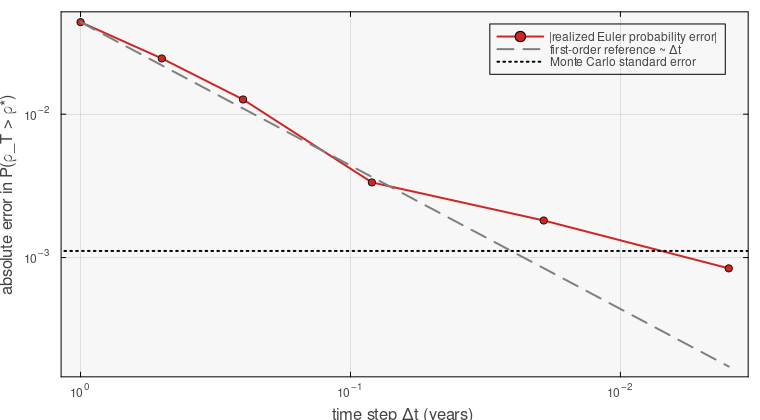

In [8]:
let
    keep = euler_table.probability_error .!= 0
    plot(euler_table.Δt[keep], abs.(euler_table.probability_error[keep]);
        xscale=:log10, yscale=:log10, marker=:circle, color=:firebrick3,
        label="|realized Euler probability error|", xlabel="time step Δt (years)",
        ylabel="absolute error in P(ρ_T > ρ*)", size=(760, 420), legend=:topright, xflip=true)
    e1 = abs(euler_table.probability_error[1])
    plot!(euler_table.Δt[keep], e1 .* (euler_table.Δt[keep] ./ euler_table.Δt[1]);
        color=:gray50, linestyle=:dash, label="first-order reference ~ Δt")
    hline!([sqrt(0.45*0.55/200_000)]; color=:black, linestyle=:dot,
        label="Monte Carlo standard error")
end

At monthly resolution the realized Euler probability error is several Monte Carlo standard errors; at weekly resolution it is about 1.6 standard errors, and at daily resolution sampling noise obscures any remaining discretization effect. A controlled bias study would repeat the simulation or couple exact and Euler paths to separate weak bias from noise.

For models that require discretization, finer steps cost more work per path and usually reduce weak bias. The GBM model avoids that trade-off because its exact transition is available in closed form.

___

## 3. Antithetic variates: making each path count twice

The standard error in Section 1 falls only as $1/\sqrt{M}$. One cheap way to do better is __antithetic variates__: for every shock vector $(Z_{1},\ldots,Z_{N})$ we also simulate the mirrored path with $(-Z_{1},\ldots,-Z_{N})$ and average the two indicators before averaging over pairs. Under GBM, $\rho_{T}$ is an increasing function of the sum of the shocks, so if one path of the pair clears the target the mirrored path tends not to; the two indicators are negatively correlated, and the average of a negatively correlated pair has less variance than the average of two independent draws. Let's implement it and compare the standard errors at equal total cost (the same number of simulated paths):

In [9]:
function simulate_target_probability_antithetic(S₀::Real, μ::Real, σ::Real, T::Real, N::Int, g_y::Real, ρ_star::Real;
        number_of_pairs::Int = 50_000, seed::Int = 5660)
    rng = MersenneTwister(seed)
    Δt = T/N
    drift = (μ - 0.5*σ^2)*Δt
    shock = σ*sqrt(Δt)
    discount = exp(-g_y*T)
    pair_average = zeros(Float64, number_of_pairs)
    for m ∈ 1:number_of_pairs
        S_plus = S₀; S_minus = S₀
        for _ ∈ 1:N
            Z = randn(rng)
            S_plus *= exp(drift + shock*Z)      # the path
            S_minus *= exp(drift - shock*Z)     # its mirror image
        end
        hit_plus = ((S_plus/S₀)*discount - 1 > ρ_star)
        hit_minus = ((S_minus/S₀)*discount - 1 > ρ_star)
        pair_average[m] = 0.5*(hit_plus + hit_minus)
    end
    p_hat = mean(pair_average)
    return (probability = p_hat, standard_error = std(pair_average)/sqrt(number_of_pairs), number_of_paths = 2*number_of_pairs)
end

variance_reduction_table = let
    df = DataFrame(method = String[], paths = Int[], estimate = Float64[], standard_error = Float64[])
    plain = simulate_target_probability(S₀, μ, σ, T, N, g_y, ρ_star; number_of_paths = 100_000)
    anti = simulate_target_probability_antithetic(S₀, μ, σ, T, N, g_y, ρ_star; number_of_pairs = 50_000)
    push!(df, ("independent paths", plain.number_of_paths, plain.probability, plain.standard_error))
    push!(df, ("antithetic pairs", anti.number_of_paths, anti.probability, anti.standard_error))
    push!(df, ("closed form", 0, p_exact, 0.0))
    df
end
pretty_table(variance_reduction_table; formatters = [fmt__printf("%.5f", [3,4])])

┌───────────────────┬────────┬──────────┬────────────────┐
│            method │  paths │ estimate │ standard_error │
│            String │  Int64 │  Float64 │        Float64 │
├───────────────────┼────────┼──────────┼────────────────┤
│ independent paths │ 100000 │  0.29404 │        0.00144 │
│  antithetic pairs │ 100000 │  0.29209 │        0.00110 │
│       closed form │      0 │  0.29331 │        0.00000 │
└───────────────────┴────────┴──────────┴────────────────┘


At the same number of simulated paths the antithetic standard error is about a quarter smaller, so it would take roughly 1.7 times as many independent paths to match it. For a monotone event with success probability $p<1/2$ the theory predicts a variance ratio of $(1-2p)/(1-p)$, about $0.59$ here, which is what we see. The saving is largest when the target probability is near one half, where a path and its mirror image almost never both clear the target, and it fades as the probability moves toward zero (or one), where the mirrored indicator is almost always zero (or one) and carries no information about the other. Antithetic sampling is the simplest member of a large family of variance-reduction methods; it costs one sign flip per shock and no additional modeling.

___

## Summary

This notebook checked the L4b closed form by simulation, showed what a naive discretization would have cost, and made the simulation more efficient.

> __Key Takeaways:__
>
> * **Simulation converges at one over the square root of the path count:** The indicator average estimates the target probability with a binomial standard error, and every additional decimal place costs one hundred times more paths.
> * **Exact transitions have no time-step bias:** The lecture's one-step transition reproduces the closed form on any grid, while the Euler scheme is biased in proportion to the step and only becomes indistinguishable from exact at fine steps.
> * **Antithetic pairs reduce variance for monotone events:** Mirroring every shock vector produces negatively correlated indicators whose average has a smaller standard error than the same number of independent paths.

Later in the course, when the price model has no closed-form transition, the Euler analysis and the variance-reduction ideas here are what make Monte Carlo usable.

___

## Disclaimer and Risks

This notebook is for instruction only. Simulation results depend on the assumed parameters, which are estimated with error, and on the random seed; the standard errors quantify sampling noise only, not model error. This material is not investment or trading advice.
